In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sys
import sqlite3
import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, NNConv

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# 2. PROJECT PATH AND DATABASE CONNECTION
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

db_path = project_root / "data" / "thesis_database.db"

print("Project root:", project_root)
print("Database path:", db_path)
print("Database exists:", db_path.exists())

conn = sqlite3.connect(db_path)

print("Connected to database")

Project root: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool
Database path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db
Database exists: True
Connected to database


In [3]:
from pathlib import Path
import sys

# Real project root
project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("project_root:", project_root)
print("project_root exists:", project_root.exists())
print("src_path:", src_path)
print("src exists:", src_path.exists())

project_root: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg
project_root exists: True
src_path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\src
src exists: True


In [4]:
# ============================================================
# 3A. FIND EVENTS FILE
# ============================================================

event_files = list(src_path.rglob("events.py"))

print(f"Found {len(event_files)} events.py file(s):")
for f in event_files:
    print(f)

Found 1 events.py file(s):
C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\src\events.py


In [5]:
# ============================================================
# 3B. IMPORT EVENT DETECTORS
# ============================================================

events_path = event_files[0]
events_folder = events_path.parent

if str(events_folder) not in sys.path:
    sys.path.append(str(events_folder))

import events
importlib.reload(events)

from events import SimpleEventDetector, CombinedEventDetector

print("Event detectors imported correctly")
print("Using events.py from:", events_path)

Event detectors imported correctly
Using events.py from: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\src\events.py


In [6]:
# ============================================================
# 4. LOAD SELECTED BIDDING ZONES
# ============================================================

zones_df = pd.read_sql_query(
    """
    SELECT *
    FROM BiddingZones
    ORDER BY zone_id;
    """,
    conn
)

selected_zone_codes = [
    "NO1", "NO2", "NO3", "NO4", "NO5",
    "SE1", "SE2", "SE3", "SE4",
    "DK1", "DK2",
    "FI",
]

selected_zones = (
    zones_df[zones_df["zone_code"].isin(selected_zone_codes)]
    .copy()
    .sort_values("zone_code")
    .reset_index(drop=True)
)

selected_zone_ids = selected_zones["zone_id"].tolist()
zone_ids_sql = ",".join(str(z) for z in selected_zone_ids)

zone_id_to_node_idx = {
    int(zone_id): idx
    for idx, zone_id in enumerate(selected_zones["zone_id"].values)
}

node_idx_to_zone_code = {
    idx: row["zone_code"]
    for idx, row in selected_zones.iterrows()
}

zone_id_to_code = dict(zip(zones_df["zone_id"], zones_df["zone_code"]))

display(selected_zones)

print("zone_id_to_node_idx:")
print(zone_id_to_node_idx)

print("node_idx_to_zone_code:")
print(node_idx_to_zone_code)

,zone_id,zone_code,country,region_id
0,9,DK1,Denmark,3
1,10,DK2,Denmark,3
2,11,FI,Finland,3
3,12,NO1,Norway,3
4,13,NO2,Norway,3
5,14,NO3,Norway,3
6,15,NO4,Norway,3
7,16,NO5,Norway,3
8,17,SE1,Sweden,3
9,18,SE2,Sweden,3


zone_id_to_node_idx:
{9: 0, 10: 1, 11: 2, 12: 3, 13: 4, 14: 5, 15: 6, 16: 7, 17: 8, 18: 9, 19: 10, 20: 11}
node_idx_to_zone_code:
{0: 'DK1', 1: 'DK2', 2: 'FI', 3: 'NO1', 4: 'NO2', 5: 'NO3', 6: 'NO4', 7: 'NO5', 8: 'SE1', 9: 'SE2', 10: 'SE3', 11: 'SE4'}


In [7]:
# ============================================================
# 5. LOAD BASE NODE DATA
# ============================================================

node_df = pd.read_sql_query(
    f"""
    SELECT
        p.zone_id,
        p.delivery_day,
        p.hour,
        p.price_value,
        v.buy_volume_value,
        v.sell_volume_value
    FROM Prices p
    LEFT JOIN Volumes v
        ON p.zone_id = v.zone_id
       AND p.delivery_day = v.delivery_day
       AND p.hour = v.hour
    WHERE p.zone_id IN ({zone_ids_sql})
    ORDER BY p.delivery_day, p.hour, p.zone_id;
    """,
    conn
)

node_df["datetime"] = (
    pd.to_datetime(node_df["delivery_day"])
    + pd.to_timedelta(node_df["hour"], unit="h")
)

node_df = node_df.sort_values(["zone_id", "datetime"]).copy()

print("Node rows:", len(node_df))
print("Datetime range:", node_df["datetime"].min(), "->", node_df["datetime"].max())

display(node_df.head(10))
display(node_df.tail(10))

Node rows: 604836
Datetime range: 2020-01-01 00:00:00 -> 2025-09-30 23:00:00


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
0,9,2020-01-01,0,33.42,1497.1,2239.7,2020-01-01 00:00:00
12,9,2020-01-01,1,31.77,1529.5,2393.3,2020-01-01 01:00:00
24,9,2020-01-01,2,31.57,1526.9,2615.4,2020-01-01 02:00:00
36,9,2020-01-01,3,31.28,1465.8,2794.3,2020-01-01 03:00:00
48,9,2020-01-01,4,30.85,1466.9,2870.0,2020-01-01 04:00:00
60,9,2020-01-01,5,30.14,1462.7,2939.1,2020-01-01 05:00:00
72,9,2020-01-01,6,30.17,1504.9,3022.4,2020-01-01 06:00:00
84,9,2020-01-01,7,30.00,1538.4,3045.2,2020-01-01 07:00:00
96,9,2020-01-01,8,30.63,1584.8,3131.2,2020-01-01 08:00:00
108,9,2020-01-01,9,30.59,1629.1,3372.8,2020-01-01 09:00:00


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
604727,20,2025-09-30,14,87.95,NaN,NaN,2025-09-30 14:00:00
604739,20,2025-09-30,15,94.85,NaN,NaN,2025-09-30 15:00:00
604751,20,2025-09-30,16,105.58,NaN,NaN,2025-09-30 16:00:00
604763,20,2025-09-30,17,137.83,NaN,NaN,2025-09-30 17:00:00
604775,20,2025-09-30,18,279.41,NaN,NaN,2025-09-30 18:00:00
604787,20,2025-09-30,19,231.30,NaN,NaN,2025-09-30 19:00:00
604799,20,2025-09-30,20,118.33,NaN,NaN,2025-09-30 20:00:00
604811,20,2025-09-30,21,102.48,NaN,NaN,2025-09-30 21:00:00
604823,20,2025-09-30,22,92.35,NaN,NaN,2025-09-30 22:00:00
604835,20,2025-09-30,23,73.62,NaN,NaN,2025-09-30 23:00:00


In [8]:
# ============================================================
# 5B. FILTER NODE DATA TO 2020
# ============================================================

start_date = pd.Timestamp("2020-01-01 00:00:00")
end_date = pd.Timestamp("2020-12-31 23:00:00")

node_df = node_df[
    (node_df["datetime"] >= start_date) &
    (node_df["datetime"] <= end_date)
].copy()

node_df = node_df.sort_values(["zone_id", "datetime"]).copy()

print("Filtered node rows:", len(node_df))
print("Datetime range:", node_df["datetime"].min(), "->", node_df["datetime"].max())

print("Missing values:")
display(node_df[["price_value", "buy_volume_value", "sell_volume_value"]].isna().sum())

display(node_df.head(10))
display(node_df.tail(10))

Filtered node rows: 105432
Datetime range: 2020-01-01 00:00:00 -> 2020-12-31 23:00:00
Missing values:


price_value          0
buy_volume_value     0
sell_volume_value    0
dtype: int64

,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
0,9,2020-01-01,0,33.42,1497.1,2239.7,2020-01-01 00:00:00
12,9,2020-01-01,1,31.77,1529.5,2393.3,2020-01-01 01:00:00
24,9,2020-01-01,2,31.57,1526.9,2615.4,2020-01-01 02:00:00
36,9,2020-01-01,3,31.28,1465.8,2794.3,2020-01-01 03:00:00
48,9,2020-01-01,4,30.85,1466.9,2870.0,2020-01-01 04:00:00
60,9,2020-01-01,5,30.14,1462.7,2939.1,2020-01-01 05:00:00
72,9,2020-01-01,6,30.17,1504.9,3022.4,2020-01-01 06:00:00
84,9,2020-01-01,7,30.00,1538.4,3045.2,2020-01-01 07:00:00
96,9,2020-01-01,8,30.63,1584.8,3131.2,2020-01-01 08:00:00
108,9,2020-01-01,9,30.59,1629.1,3372.8,2020-01-01 09:00:00


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime
105323,20,2020-12-31,14,53.08,2599.1,576.4,2020-12-31 14:00:00
105335,20,2020-12-31,15,56.54,2706.5,580.7,2020-12-31 15:00:00
105347,20,2020-12-31,16,59.20,2852.4,582.8,2020-12-31 16:00:00
105359,20,2020-12-31,17,61.34,2860.3,588.7,2020-12-31 17:00:00
105371,20,2020-12-31,18,61.08,2743.6,589.7,2020-12-31 18:00:00
105383,20,2020-12-31,19,58.04,2629.3,577.3,2020-12-31 19:00:00
105395,20,2020-12-31,20,54.45,2527.7,538.0,2020-12-31 20:00:00
105407,20,2020-12-31,21,51.18,2452.0,464.6,2020-12-31 21:00:00
105419,20,2020-12-31,22,45.84,2397.3,450.7,2020-12-31 22:00:00
105431,20,2020-12-31,23,24.07,2335.7,392.8,2020-12-31 23:00:00


In [9]:
# ============================================================
# 6. DETECT NODE EVENTS
# ============================================================

simple_detector = SimpleEventDetector()
combined_detector = CombinedEventDetector()

node_df_events = node_df.copy()

# Price events
node_df_events = simple_detector.detect_price_events(node_df_events)

# Volume events
node_df_events = simple_detector.detect_volume_events(node_df_events)

# Combined price + volume events
node_df_events = combined_detector.detect_combined_events(node_df_events)

print("Node dataframe with events:")
display(node_df_events.head(10))

print("Number of columns:", len(node_df_events.columns))

print("Event columns preview:")
event_cols_preview = [
    "low_price",
    "high_price",
    "price_spike",
    "rapid_price_change",
    "high_demand",
    "low_demand",
    "high_generation",
    "low_generation",
    "generation_surplus",
    "demand_pressure",
    "scarcity_price_event",
    "oversupply_price_event",
]

display(node_df_events[event_cols_preview].head(10))

print("Event counts:")
display(node_df_events[event_cols_preview].sum().sort_values(ascending=False))

Node dataframe with events:


,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime,price_delta,abs_price_delta,rolling_volatility_24h,...,sell_pressure_low_price,system_price_max,system_price_min,system_price_spread,price_separation,extreme_price_separation,system_price_median,price_deviation_from_system,zone_price_outlier,has_combined_event
0,9,2020-01-01,0,33.42,1497.1,2239.7,2020-01-01 00:00:00,NaN,NaN,NaN,...,False,33.42,28.78,4.64,False,False,28.78,4.64,False,False
12,9,2020-01-01,1,31.77,1529.5,2393.3,2020-01-01 01:00:00,-1.65,1.65,NaN,...,False,31.77,28.45,3.32,False,False,28.45,3.32,False,False
24,9,2020-01-01,2,31.57,1526.9,2615.4,2020-01-01 02:00:00,-0.20,0.20,NaN,...,False,31.57,27.90,3.67,False,False,27.90,3.67,False,False
36,9,2020-01-01,3,31.28,1465.8,2794.3,2020-01-01 03:00:00,-0.29,0.29,NaN,...,False,31.28,27.52,3.76,False,False,27.52,3.76,False,False
48,9,2020-01-01,4,30.85,1466.9,2870.0,2020-01-01 04:00:00,-0.43,0.43,NaN,...,False,30.85,27.54,3.31,False,False,27.54,3.31,False,False
60,9,2020-01-01,5,30.14,1462.7,2939.1,2020-01-01 05:00:00,-0.71,0.71,1.103136,...,False,30.27,26.55,3.72,False,False,26.55,3.59,False,False
72,9,2020-01-01,6,30.17,1504.9,3022.4,2020-01-01 06:00:00,0.03,0.03,1.126364,...,False,30.17,25.83,4.34,False,False,25.83,4.34,False,False
84,9,2020-01-01,7,30.00,1538.4,3045.2,2020-01-01 07:00:00,-0.17,0.17,1.141653,...,False,30.14,25.07,5.07,False,False,25.07,4.93,False,False
96,9,2020-01-01,8,30.63,1584.8,3131.2,2020-01-01 08:00:00,0.63,0.63,1.081894,...,False,30.63,25.65,4.98,False,False,25.65,4.98,False,False
108,9,2020-01-01,9,30.59,1629.1,3372.8,2020-01-01 09:00:00,-0.04,0.04,1.032309,...,False,30.59,26.15,4.44,False,False,26.15,4.44,False,False


Number of columns: 50
Event columns preview:


,low_price,high_price,price_spike,rapid_price_change,high_demand,low_demand,high_generation,low_generation,generation_surplus,demand_pressure,scarcity_price_event,oversupply_price_event
0,False,False,False,False,False,False,False,False,False,False,False,False
12,False,False,False,False,False,False,False,False,False,False,False,False
24,False,False,False,False,False,False,False,False,False,False,False,False
36,False,False,False,False,False,False,False,False,False,False,False,False
48,False,False,False,False,False,False,False,False,False,False,False,False
60,False,False,False,False,False,True,False,False,False,False,False,False
72,False,False,False,False,False,False,False,False,False,False,False,False
84,False,False,False,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False,False,False,False
108,False,False,False,False,False,False,False,False,False,False,False,False


Event counts:


high_generation           10548
high_demand               10545
low_generation            10543
low_demand                10543
high_price                10535
low_price                 10495
price_spike                5278
rapid_price_change         5265
generation_surplus           93
demand_pressure              69
oversupply_price_event       32
scarcity_price_event         18
dtype: int64

In [10]:
# ============================================================
# 7. ADD TARGET AND LAG FEATURES
# ============================================================

node_df_events = node_df_events.sort_values(["zone_id", "datetime"]).copy()

# Target t+1
node_df_events["target_price_t_plus_1"] = (
    node_df_events.groupby("zone_id")["price_value"]
    .shift(-1)
)

# Price lags
lags = [1, 2, 24]

for lag in lags:
    node_df_events[f"price_lag_{lag}"] = (
        node_df_events.groupby("zone_id")["price_value"]
        .shift(lag)
    )

print("Missing values in lags and target:")
display(
    node_df_events[
        ["target_price_t_plus_1", "price_lag_1", "price_lag_2", "price_lag_24"]
    ].isna().sum()
)

display(node_df_events.head(30))

Missing values in lags and target:


target_price_t_plus_1     12
price_lag_1               12
price_lag_2               24
price_lag_24             288
dtype: int64

,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value,datetime,price_delta,abs_price_delta,rolling_volatility_24h,...,price_separation,extreme_price_separation,system_price_median,price_deviation_from_system,zone_price_outlier,has_combined_event,target_price_t_plus_1,price_lag_1,price_lag_2,price_lag_24
0,9,2020-01-01,0,33.42,1497.1,2239.7,2020-01-01 00:00:00,NaN,NaN,NaN,...,False,False,28.78,4.64,False,False,31.77,NaN,NaN,NaN
12,9,2020-01-01,1,31.77,1529.5,2393.3,2020-01-01 01:00:00,-1.65,1.65,NaN,...,False,False,28.45,3.32,False,False,31.57,33.42,NaN,NaN
24,9,2020-01-01,2,31.57,1526.9,2615.4,2020-01-01 02:00:00,-0.20,0.20,NaN,...,False,False,27.90,3.67,False,False,31.28,31.77,33.42,NaN
36,9,2020-01-01,3,31.28,1465.8,2794.3,2020-01-01 03:00:00,-0.29,0.29,NaN,...,False,False,27.52,3.76,False,False,30.85,31.57,31.77,NaN
48,9,2020-01-01,4,30.85,1466.9,2870.0,2020-01-01 04:00:00,-0.43,0.43,NaN,...,False,False,27.54,3.31,False,False,30.14,31.28,31.57,NaN
60,9,2020-01-01,5,30.14,1462.7,2939.1,2020-01-01 05:00:00,-0.71,0.71,1.103136,...,False,False,26.55,3.59,False,False,30.17,30.85,31.28,NaN
72,9,2020-01-01,6,30.17,1504.9,3022.4,2020-01-01 06:00:00,0.03,0.03,1.126364,...,False,False,25.83,4.34,False,False,30.00,30.14,30.85,NaN
84,9,2020-01-01,7,30.00,1538.4,3045.2,2020-01-01 07:00:00,-0.17,0.17,1.141653,...,False,False,25.07,4.93,False,False,30.63,30.17,30.14,NaN
96,9,2020-01-01,8,30.63,1584.8,3131.2,2020-01-01 08:00:00,0.63,0.63,1.081894,...,False,False,25.65,4.98,False,False,30.59,30.00,30.17,NaN
108,9,2020-01-01,9,30.59,1629.1,3372.8,2020-01-01 09:00:00,-0.04,0.04,1.032309,...,False,False,26.15,4.44,False,False,30.27,30.63,30.00,NaN


In [11]:
# ============================================================
# 8. DEFINE NODE FEATURE COLUMNS WITH EVENTS
# ============================================================

base_node_features = [
    "price_value",
    "buy_volume_value",
    "sell_volume_value",
    "price_lag_1",
    "price_lag_2",
    "price_lag_24",
]

price_event_features = [
    "low_price",
    "high_price",
    "price_spike",
    "extreme_price",
    "rapid_price_change",
    "price_ramp_up",
    "price_ramp_down",
    "high_volatility",
]

volume_event_features = [
    "high_demand",
    "low_demand",
    "high_generation",
    "low_generation",
    "strong_buy_pressure",
    "strong_sell_pressure",
    "buy_volume_spike",
    "sell_volume_spike",
]

combined_event_features = [
    "generation_surplus",
    "demand_pressure",
    "strong_demand_pressure",
    "strong_generation_pressure",
    "demand_driven_price_spike",
    "generation_driven_low_price",
    "scarcity_price_event",
    "oversupply_price_event",
    "buy_pressure_price_spike",
    "sell_pressure_low_price",
    "price_separation",
    "extreme_price_separation",
    "zone_price_outlier",
]

node_event_features = (
    price_event_features
    + volume_event_features
    + combined_event_features
)

node_feature_columns_events = (
    base_node_features
    + node_event_features
)

print("Number of base features:", len(base_node_features))
print("Number of price event features:", len(price_event_features))
print("Number of volume event features:", len(volume_event_features))
print("Number of combined event features:", len(combined_event_features))
print("Number of event features:", len(node_event_features))
print("Total node features:", len(node_feature_columns_events))

print("\nNode feature columns:")
for col in node_feature_columns_events:
    print("-", col)

missing_cols = [
    col for col in node_feature_columns_events
    if col not in node_df_events.columns
]

print("\nMissing columns:", missing_cols)

Number of base features: 6
Number of price event features: 8
Number of volume event features: 8
Number of combined event features: 13
Number of event features: 29
Total node features: 35

Node feature columns:
- price_value
- buy_volume_value
- sell_volume_value
- price_lag_1
- price_lag_2
- price_lag_24
- low_price
- high_price
- price_spike
- extreme_price
- rapid_price_change
- price_ramp_up
- price_ramp_down
- high_volatility
- high_demand
- low_demand
- high_generation
- low_generation
- strong_buy_pressure
- strong_sell_pressure
- buy_volume_spike
- sell_volume_spike
- generation_surplus
- demand_pressure
- strong_demand_pressure
- strong_generation_pressure
- demand_driven_price_spike
- generation_driven_low_price
- scarcity_price_event
- oversupply_price_event
- buy_pressure_price_spike
- sell_pressure_low_price
- price_separation
- extreme_price_separation
- zone_price_outlier

Missing columns: []


In [12]:
# ============================================================
# 9. CONVERT EVENT FEATURES TO FLOAT AND CHECK MISSING VALUES
# ============================================================

node_df_events = node_df_events.copy()

# Convert boolean event columns to float: False -> 0.0, True -> 1.0
for col in node_event_features:
    node_df_events[col] = node_df_events[col].astype(float)

print("Feature preview:")
display(node_df_events[node_feature_columns_events].head(10))

print("Missing values in selected node features:")
missing_features = (
    node_df_events[node_feature_columns_events]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing_features[missing_features > 0])

print("Total missing values in selected node features:")
print(node_df_events[node_feature_columns_events].isna().sum().sum())

print("Data types:")
display(node_df_events[node_feature_columns_events].dtypes.value_counts())

Feature preview:


,price_value,buy_volume_value,sell_volume_value,price_lag_1,price_lag_2,price_lag_24,low_price,high_price,price_spike,extreme_price,...,strong_generation_pressure,demand_driven_price_spike,generation_driven_low_price,scarcity_price_event,oversupply_price_event,buy_pressure_price_spike,sell_pressure_low_price,price_separation,extreme_price_separation,zone_price_outlier
0,33.42,1497.1,2239.7,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,31.77,1529.5,2393.3,33.42,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,31.57,1526.9,2615.4,31.77,33.42,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36,31.28,1465.8,2794.3,31.57,31.77,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48,30.85,1466.9,2870.0,31.28,31.57,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,30.14,1462.7,2939.1,30.85,31.28,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72,30.17,1504.9,3022.4,30.14,30.85,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84,30.00,1538.4,3045.2,30.17,30.14,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,30.63,1584.8,3131.2,30.00,30.17,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108,30.59,1629.1,3372.8,30.63,30.00,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Missing values in selected node features:


price_lag_24    288
price_lag_2      24
price_lag_1      12
dtype: int64

Total missing values in selected node features:
324
Data types:


float64    35
Name: count, dtype: int64

In [13]:
# ============================================================
# 10. LOAD FLOWS, CAPACITIES AND BUILD EDGE INDEX
# ============================================================

flows_no = pd.read_sql_query(
    f"""
    SELECT *
    FROM Flows
    WHERE from_zone_id IN ({zone_ids_sql})
      AND to_zone_id IN ({zone_ids_sql})
    ORDER BY delivery_day, hour, from_zone_id, to_zone_id;
    """,
    conn
)

capacities_no = pd.read_sql_query(
    f"""
    SELECT *
    FROM Capacities
    WHERE from_zone_id IN ({zone_ids_sql})
      AND to_zone_id IN ({zone_ids_sql})
    ORDER BY delivery_day, hour, from_zone_id, to_zone_id;
    """,
    conn
)

flows_no["datetime"] = (
    pd.to_datetime(flows_no["delivery_day"])
    + pd.to_timedelta(flows_no["hour"], unit="h")
)

capacities_no["datetime"] = (
    pd.to_datetime(capacities_no["delivery_day"])
    + pd.to_timedelta(capacities_no["hour"], unit="h")
)

edge_df = flows_no.merge(
    capacities_no[
        [
            "from_zone_id",
            "to_zone_id",
            "datetime",
            "capacity_value",
        ]
    ],
    on=["from_zone_id", "to_zone_id", "datetime"],
    how="left"
)

unique_edges = (
    edge_df[["from_zone_id", "to_zone_id"]]
    .drop_duplicates()
    .sort_values(["from_zone_id", "to_zone_id"])
    .reset_index(drop=True)
)

edge_index_list = []

for _, row in unique_edges.iterrows():
    from_node_idx = zone_id_to_node_idx[int(row["from_zone_id"])]
    to_node_idx = zone_id_to_node_idx[int(row["to_zone_id"])]
    edge_index_list.append([from_node_idx, to_node_idx])

edge_index = np.array(edge_index_list).T

unique_edges_named = unique_edges.copy()
unique_edges_named["from_zone_code"] = unique_edges_named["from_zone_id"].map(zone_id_to_code)
unique_edges_named["to_zone_code"] = unique_edges_named["to_zone_id"].map(zone_id_to_code)

display(unique_edges_named)

print("Flow rows:", len(flows_no))
print("Capacity rows:", len(capacities_no))
print("Edge rows after merge:", len(edge_df))
print("Missing capacity values:", edge_df["capacity_value"].isna().sum())

print("Edge datetime range:", edge_df["datetime"].min(), "->", edge_df["datetime"].max())
print("Number of unique directed edges:", len(unique_edges))
print("edge_index shape:", edge_index.shape)
print(edge_index)

,from_zone_id,to_zone_id,from_zone_code,to_zone_code
0,9,13,DK1,NO2
1,11,15,FI,NO4
2,12,13,NO1,NO2
3,12,14,NO1,NO3
4,12,16,NO1,NO5
5,12,19,NO1,SE3
6,13,9,NO2,DK1
7,13,12,NO2,NO1
8,13,16,NO2,NO5
9,14,12,NO3,NO1


Flow rows: 210792
Capacity rows: 158094
Edge rows after merge: 210792
Missing capacity values: 52698
Edge datetime range: 2020-01-01 00:00:00 -> 2020-12-31 23:00:00
Number of unique directed edges: 24
edge_index shape: (2, 24)
[[ 0  2  3  3  3  3  4  4  4  5  5  5  5  6  6  6  6  7  7  7  8  9  9 10]
 [ 4  6  4  5  7 10  0  3  7  3  6  7  9  2  5  8  9  3  4  5  6  5  6  3]]


In [18]:
# ============================================================
# 11. CREATE EDGE FEATURES AND EDGE EVENTS
# ============================================================

edge_df = edge_df.sort_values(
    ["from_zone_id", "to_zone_id", "datetime"]
).copy()

# ------------------------------------------------------------
# Handle missing capacities
# ------------------------------------------------------------
# Some directional edges may not have capacity values for all hours.
# We fill missing values per edge using forward/backward fill.
edge_df["capacity_value"] = (
    edge_df
    .groupby(["from_zone_id", "to_zone_id"])["capacity_value"]
    .ffill()
    .bfill()
)

# If some edges still have missing capacity, replace with 0
edge_df["capacity_value"] = edge_df["capacity_value"].fillna(0)

# ------------------------------------------------------------
# Basic edge features
# ------------------------------------------------------------
edge_df["abs_flow_value"] = edge_df["flow_value"].abs()

# Avoid division by zero
edge_df["utilization"] = np.where(
    edge_df["capacity_value"] > 0,
    edge_df["abs_flow_value"] / edge_df["capacity_value"],
    0
)

# Cap extreme utilization values to avoid exploding features
edge_df["utilization"] = edge_df["utilization"].clip(lower=0, upper=2)

# ------------------------------------------------------------
# Edge event thresholds computed per directed edge
# ------------------------------------------------------------
edge_df["flow_p90"] = (
    edge_df
    .groupby(["from_zone_id", "to_zone_id"])["abs_flow_value"]
    .transform(lambda x: x.quantile(0.90))
)

edge_df["capacity_p10"] = (
    edge_df
    .groupby(["from_zone_id", "to_zone_id"])["capacity_value"]
    .transform(lambda x: x.quantile(0.10))
)

# ------------------------------------------------------------
# Edge events
# ------------------------------------------------------------

# High flow event: flow is unusually high for that directed edge
edge_df["high_flow_event"] = (
    edge_df["abs_flow_value"] > edge_df["flow_p90"]
).astype(int)

# Low capacity event: capacity is unusually low for that directed edge
edge_df["low_capacity_event"] = (
    edge_df["capacity_value"] < edge_df["capacity_p10"]
).astype(int)

# Congestion event: flow is close to or above available capacity
edge_df["congestion_event"] = (
    edge_df["utilization"] >= 0.90
).astype(int)

# Flow reversal event:
# flow changes sign compared to previous hour for the same directed edge
edge_df["previous_flow_value"] = (
    edge_df
    .groupby(["from_zone_id", "to_zone_id"])["flow_value"]
    .shift(1)
)

edge_df["flow_reversal_event"] = (
    (edge_df["flow_value"] * edge_df["previous_flow_value"] < 0)
).astype(int)

edge_df["flow_reversal_event"] = edge_df["flow_reversal_event"].fillna(0).astype(int)

# ------------------------------------------------------------
# Clean helper columns if desired
# ------------------------------------------------------------
edge_event_cols = [
    "high_flow_event",
    "low_capacity_event",
    "congestion_event",
]

edge_feature_cols = [
    "flow_value",
    "capacity_value",
    "utilization",
    "high_flow_event",
    "low_capacity_event",
    "congestion_event"
]

print("Missing capacity after fill:", edge_df["capacity_value"].isna().sum())
print("Edge feature columns:")
print(edge_feature_cols)

print("\nEdge event counts:")
display(edge_df[edge_event_cols].sum().to_frame("count"))

print("\nEdge feature sample:")
display(edge_df[
    [
        "datetime",
        "from_zone_id",
        "to_zone_id",
        "flow_value",
        "capacity_value",
        "utilization",
        "high_flow_event",
        "low_capacity_event",
        "congestion_event"
    ]
].head(20))

Missing capacity after fill: 0
Edge feature columns:
['flow_value', 'capacity_value', 'utilization', 'high_flow_event', 'low_capacity_event', 'congestion_event']

Edge event counts:


,count
high_flow_event,12558
low_capacity_event,7388
congestion_event,61374



Edge feature sample:


,datetime,from_zone_id,to_zone_id,flow_value,capacity_value,utilization,high_flow_event,low_capacity_event,congestion_event
0,2020-01-01 00:00:00,9,13,0.0,0.0,0.0,0,0,0
24,2020-01-01 01:00:00,9,13,0.0,0.0,0.0,0,0,0
48,2020-01-01 02:00:00,9,13,0.0,0.0,0.0,0,0,0
72,2020-01-01 03:00:00,9,13,275.0,0.0,0.0,1,0,0
96,2020-01-01 04:00:00,9,13,628.4,0.0,0.0,1,0,0
120,2020-01-01 05:00:00,9,13,1228.4,0.0,0.0,1,0,0
144,2020-01-01 06:00:00,9,13,1380.2,0.0,0.0,1,0,0
168,2020-01-01 07:00:00,9,13,1225.8,0.0,0.0,1,0,0
192,2020-01-01 08:00:00,9,13,625.8,0.0,0.0,1,0,0
216,2020-01-01 09:00:00,9,13,862.7,0.0,0.0,1,0,0


In [19]:
# ============================================================
# 12. PREPARE NODE AND EDGE DATA FOR GRAPH DATASET
# ============================================================

# ------------------------------------------------------------
# Clean node data: keep only rows with all required features and target
# ------------------------------------------------------------

required_node_cols = (
    ["datetime", "zone_id", "target_price_t_plus_1"]
    + node_feature_columns_events
)

node_df_model = node_df_events[required_node_cols].copy()

node_df_model = node_df_model.dropna(
    subset=node_feature_columns_events + ["target_price_t_plus_1"]
).copy()

node_df_model = node_df_model.sort_values(["datetime", "zone_id"]).copy()

print("Node model rows:", len(node_df_model))
print("Datetime range:", node_df_model["datetime"].min(), "->", node_df_model["datetime"].max())

# ------------------------------------------------------------
# Keep only datetimes where all selected zones are present
# ------------------------------------------------------------

n_nodes = len(selected_zone_ids)

nodes_per_datetime = (
    node_df_model
    .groupby("datetime")["zone_id"]
    .nunique()
)

complete_node_datetimes = nodes_per_datetime[
    nodes_per_datetime == n_nodes
].index

node_df_model = node_df_model[
    node_df_model["datetime"].isin(complete_node_datetimes)
].copy()

print("Complete node datetimes:", len(complete_node_datetimes))
print("Node rows after complete datetime filter:", len(node_df_model))

# ------------------------------------------------------------
# Build edge attributes by datetime
# ------------------------------------------------------------

edge_attr_by_datetime = {}

for dt, group in edge_df.groupby("datetime"):
    group = group.copy()

    # Ensure edge order is always the same as unique_edges / edge_index
    group = unique_edges.merge(
        group,
        on=["from_zone_id", "to_zone_id"],
        how="left"
    )

    # Fill missing edge feature values for missing edges at this datetime
    group[edge_feature_cols] = group[edge_feature_cols].fillna(0)

    edge_attr_by_datetime[dt] = group[edge_feature_cols].values.astype(float)

complete_edge_datetimes = set(edge_attr_by_datetime.keys())

# ------------------------------------------------------------
# Keep only datetimes with both complete node data and edge attributes
# ------------------------------------------------------------

valid_datetimes = sorted(
    set(complete_node_datetimes).intersection(complete_edge_datetimes)
)

node_df_model = node_df_model[
    node_df_model["datetime"].isin(valid_datetimes)
].copy()

print("Valid graph datetimes:", len(valid_datetimes))
print("Final node rows:", len(node_df_model))
print("Expected node rows:", len(valid_datetimes) * n_nodes)

print("\nEdge feature dimension:", len(edge_feature_cols))
print("Node feature dimension:", len(node_feature_columns_events))
print("Number of edges:", edge_index.shape[1])

Node model rows: 105132
Datetime range: 2020-01-02 00:00:00 -> 2020-12-31 22:00:00
Complete node datetimes: 8758
Node rows after complete datetime filter: 105132
Valid graph datetimes: 8758
Final node rows: 105132
Expected node rows: 105096

Edge feature dimension: 6
Node feature dimension: 35
Number of edges: 24


In [20]:
# ============================================================
# 12A. DEBUG DUPLICATED NODE DATETIMES
# ============================================================

duplicates_node = (
    node_df_model
    .groupby(["datetime", "zone_id"])
    .size()
    .reset_index(name="count")
)

duplicates_node = duplicates_node[duplicates_node["count"] > 1]

print("Number of duplicated datetime-zone pairs:", len(duplicates_node))

display(duplicates_node.head(50))

if len(duplicates_node) > 0:
    duplicated_datetimes = duplicates_node["datetime"].unique()
    print("Duplicated datetimes:")
    print(duplicated_datetimes[:20])

    sample_dt = duplicated_datetimes[0]

    print("\nSample duplicated datetime:")
    print(sample_dt)

    display(
        node_df_model[node_df_model["datetime"] == sample_dt]
        .sort_values(["zone_id"])
    )

Number of duplicated datetime-zone pairs: 12


,datetime,zone_id,count
85548,2020-10-25 02:00:00,9,4
85549,2020-10-25 02:00:00,10,4
85550,2020-10-25 02:00:00,11,4
85551,2020-10-25 02:00:00,12,4
85552,2020-10-25 02:00:00,13,4
85553,2020-10-25 02:00:00,14,4
85554,2020-10-25 02:00:00,15,4
85555,2020-10-25 02:00:00,16,4
85556,2020-10-25 02:00:00,17,4
85557,2020-10-25 02:00:00,18,4


Duplicated datetimes:
<DatetimeArray>
['2020-10-25 02:00:00']
Length: 1, dtype: datetime64[us]

Sample duplicated datetime:
2020-10-25 02:00:00


,datetime,zone_id,target_price_t_plus_1,price_value,buy_volume_value,sell_volume_value,price_lag_1,price_lag_2,price_lag_24,low_price,...,strong_generation_pressure,demand_driven_price_spike,generation_driven_low_price,scarcity_price_event,oversupply_price_event,buy_pressure_price_spike,sell_pressure_low_price,price_separation,extreme_price_separation,zone_price_outlier
85836,2020-10-25 02:00:00,9,0.15,0.15,1401.6,3547.3,0.06,0.05,13.11,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
85837,2020-10-25 02:00:00,9,0.09,0.15,1411.1,3414.5,0.15,0.06,13.14,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
85838,2020-10-25 02:00:00,9,0.09,0.09,1401.6,3547.3,0.15,0.15,13.20,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
85839,2020-10-25 02:00:00,9,-0.10,0.09,1411.1,3414.5,0.09,0.15,13.50,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
85840,2020-10-25 02:00:00,10,0.15,0.15,930.3,653.7,8.97,11.47,13.11,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
85841,2020-10-25 02:00:00,10,0.09,0.15,930.9,667.0,0.15,8.97,13.14,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
85842,2020-10-25 02:00:00,10,0.09,0.09,930.3,653.7,0.15,0.15,13.20,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
85843,2020-10-25 02:00:00,10,-0.10,0.09,930.9,667.0,0.09,0.15,13.50,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
85844,2020-10-25 02:00:00,11,7.28,7.28,5533.3,4139.7,8.97,11.47,13.11,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
85845,2020-10-25 02:00:00,11,6.65,7.28,5561.0,4114.2,7.28,8.97,13.14,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# ============================================================
# 12B. REMOVE AMBIGUOUS DST DATETIMES
# ============================================================

# Detect datetime-zone pairs with more than one row
duplicates_node = (
    node_df_model
    .groupby(["datetime", "zone_id"])
    .size()
    .reset_index(name="count")
)

ambiguous_datetimes = duplicates_node.loc[
    duplicates_node["count"] > 1,
    "datetime"
].unique()

print("Ambiguous datetimes detected:")
print(ambiguous_datetimes)

# Remove ambiguous datetimes from node data
node_df_model = node_df_model[
    ~node_df_model["datetime"].isin(ambiguous_datetimes)
].copy()

# Remove ambiguous datetimes from edge data too
edge_df = edge_df[
    ~edge_df["datetime"].isin(ambiguous_datetimes)
].copy()

print("Node rows after removing ambiguous datetimes:", len(node_df_model))
print("Edge rows after removing ambiguous datetimes:", len(edge_df))

# Rebuild edge attributes by datetime after filtering
edge_attr_by_datetime = {}

for dt, group in edge_df.groupby("datetime"):
    group = group.copy()

    # Ensure edge order is always the same as unique_edges / edge_index
    group = unique_edges.merge(
        group,
        on=["from_zone_id", "to_zone_id"],
        how="left"
    )

    group[edge_feature_cols] = group[edge_feature_cols].fillna(0)

    edge_attr_by_datetime[dt] = group[edge_feature_cols].values.astype(float)

# Recompute valid datetimes
nodes_per_datetime = (
    node_df_model
    .groupby("datetime")["zone_id"]
    .nunique()
)

complete_node_datetimes = nodes_per_datetime[
    nodes_per_datetime == n_nodes
].index

valid_datetimes = sorted(
    set(complete_node_datetimes).intersection(set(edge_attr_by_datetime.keys()))
)

node_df_model = node_df_model[
    node_df_model["datetime"].isin(valid_datetimes)
].copy()

print("Valid graph datetimes after DST removal:", len(valid_datetimes))
print("Final node rows after DST removal:", len(node_df_model))
print("Expected node rows:", len(valid_datetimes) * n_nodes)

# Final duplicate check
check_duplicates = (
    node_df_model
    .groupby(["datetime", "zone_id"])
    .size()
    .reset_index(name="count")
)

print("Remaining duplicated datetime-zone pairs:")
display(check_duplicates[check_duplicates["count"] > 1])

Ambiguous datetimes detected:
<DatetimeArray>
['2020-10-25 02:00:00']
Length: 1, dtype: datetime64[us]
Node rows after removing ambiguous datetimes: 105084
Edge rows after removing ambiguous datetimes: 210768
Valid graph datetimes after DST removal: 8757
Final node rows after DST removal: 105084
Expected node rows: 105084
Remaining duplicated datetime-zone pairs:


,datetime,zone_id,count


In [22]:
# ============================================================
# 13. TRAIN / TEST SPLIT
# ============================================================

valid_datetimes = sorted(valid_datetimes)

# Same split idea as previous experiments: train until Nov 30, test Dec 1-7
train_end = pd.Timestamp("2020-11-30 23:00:00")
test_start = pd.Timestamp("2020-12-01 00:00:00")
test_end = pd.Timestamp("2020-12-07 23:00:00")

train_datetimes = [
    dt for dt in valid_datetimes
    if dt <= train_end
]

test_datetimes = [
    dt for dt in valid_datetimes
    if test_start <= dt <= test_end
]

print("Train datetimes:", len(train_datetimes))
print("Test datetimes:", len(test_datetimes))

print("Train range:", min(train_datetimes), "->", max(train_datetimes))
print("Test range:", min(test_datetimes), "->", max(test_datetimes))

Train datetimes: 8014
Test datetimes: 168
Train range: 2020-01-02 00:00:00 -> 2020-11-30 23:00:00
Test range: 2020-12-01 00:00:00 -> 2020-12-07 23:00:00


In [23]:
# ============================================================
# 14. NORMALIZE NODE AND EDGE FEATURES
# ============================================================

node_df_model = node_df_model.copy()
edge_df = edge_df.copy()

# ------------------------------------------------------------
# Node feature normalization using train period only
# ------------------------------------------------------------

train_node_mask = node_df_model["datetime"].isin(train_datetimes)

node_feature_means = node_df_model.loc[
    train_node_mask,
    node_feature_columns_events
].mean()

node_feature_stds = node_df_model.loc[
    train_node_mask,
    node_feature_columns_events
].std()

node_feature_stds = node_feature_stds.replace(0, 1)

node_df_model[node_feature_columns_events] = (
    node_df_model[node_feature_columns_events] - node_feature_means
) / node_feature_stds

# ------------------------------------------------------------
# Edge feature normalization using train period only
# ------------------------------------------------------------

train_edge_mask = edge_df["datetime"].isin(train_datetimes)

edge_feature_means = edge_df.loc[
    train_edge_mask,
    edge_feature_cols
].mean()

edge_feature_stds = edge_df.loc[
    train_edge_mask,
    edge_feature_cols
].std()

edge_feature_stds = edge_feature_stds.replace(0, 1)

edge_df[edge_feature_cols] = (
    edge_df[edge_feature_cols] - edge_feature_means
) / edge_feature_stds

# ------------------------------------------------------------
# Rebuild edge attributes after normalization
# ------------------------------------------------------------

edge_attr_by_datetime = {}

for dt, group in edge_df.groupby("datetime"):
    group = group.copy()

    group = unique_edges.merge(
        group,
        on=["from_zone_id", "to_zone_id"],
        how="left"
    )

    group[edge_feature_cols] = group[edge_feature_cols].fillna(0)

    edge_attr_by_datetime[dt] = group[edge_feature_cols].values.astype(float)

print("Node features normalized:", len(node_feature_columns_events))
print("Edge features normalized:", len(edge_feature_cols))

print("Any missing node features after normalization:")
print(node_df_model[node_feature_columns_events].isna().sum().sum())

print("Any missing edge features after normalization:")
print(edge_df[edge_feature_cols].isna().sum().sum())

Node features normalized: 35
Edge features normalized: 6
Any missing node features after normalization:
0
Any missing edge features after normalization:
0


In [24]:
# ============================================================
# 15. BUILD PYTORCH GEOMETRIC GRAPH DATASET
# ============================================================

edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)

graph_list = []

for dt in valid_datetimes:
    current_nodes = (
        node_df_model[node_df_model["datetime"] == dt]
        .copy()
        .sort_values("zone_id")
    )

    # Safety check: one row per selected zone
    if len(current_nodes) != n_nodes:
        continue

    x = torch.tensor(
        current_nodes[node_feature_columns_events].values,
        dtype=torch.float
    )

    y = torch.tensor(
        current_nodes["target_price_t_plus_1"].values,
        dtype=torch.float
    )

    edge_attr = torch.tensor(
        edge_attr_by_datetime[dt],
        dtype=torch.float
    )

    data = Data(
        x=x,
        edge_index=edge_index_tensor,
        edge_attr=edge_attr,
        y=y
    )

    data.datetime = dt

    graph_list.append(data)

print("Number of graphs:", len(graph_list))
print("First graph:")
print(graph_list[0])

print("x shape:", graph_list[0].x.shape)
print("edge_index shape:", graph_list[0].edge_index.shape)
print("edge_attr shape:", graph_list[0].edge_attr.shape)
print("y shape:", graph_list[0].y.shape)
print("datetime:", graph_list[0].datetime)

Number of graphs: 8757
First graph:
Data(x=[12, 35], edge_index=[2, 24], edge_attr=[24, 6], y=[12], datetime=2020-01-02 00:00:00)
x shape: torch.Size([12, 35])
edge_index shape: torch.Size([2, 24])
edge_attr shape: torch.Size([24, 6])
y shape: torch.Size([12])
datetime: 2020-01-02 00:00:00


In [25]:
# ============================================================
# 16. CREATE TRAIN AND TEST GRAPH LISTS
# ============================================================

train_graphs = [
    graph for graph in graph_list
    if graph.datetime in train_datetimes
]

test_graphs = [
    graph for graph in graph_list
    if graph.datetime in test_datetimes
]

print("Train graphs:", len(train_graphs))
print("Test graphs:", len(test_graphs))

print("Train range:", train_graphs[0].datetime, "->", train_graphs[-1].datetime)
print("Test range:", test_graphs[0].datetime, "->", test_graphs[-1].datetime)

print("Example train graph:", train_graphs[0])
print("Example test graph:", test_graphs[0])

Train graphs: 8014
Test graphs: 168
Train range: 2020-01-02 00:00:00 -> 2020-11-30 23:00:00
Test range: 2020-12-01 00:00:00 -> 2020-12-07 23:00:00
Example train graph: Data(x=[12, 35], edge_index=[2, 24], edge_attr=[24, 6], y=[12], datetime=2020-01-02 00:00:00)
Example test graph: Data(x=[12, 35], edge_index=[2, 24], edge_attr=[24, 6], y=[12], datetime=2020-12-01 00:00:00)


In [26]:
# ============================================================
# 17. CREATE DATALOADERS
# ============================================================

batch_size = 32

train_loader = DataLoader(
    train_graphs,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_graphs,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

batch = next(iter(train_loader))

print(batch)
print("Batch x shape:", batch.x.shape)
print("Batch edge_index shape:", batch.edge_index.shape)
print("Batch edge_attr shape:", batch.edge_attr.shape)
print("Batch y shape:", batch.y.shape)
print("Batch batch vector shape:", batch.batch.shape)

Train batches: 251
Test batches: 6
DataBatch(x=[384, 35], edge_index=[2, 768], edge_attr=[768, 6], y=[384], datetime=[32], batch=[384], ptr=[33])
Batch x shape: torch.Size([384, 35])
Batch edge_index shape: torch.Size([2, 768])
Batch edge_attr shape: torch.Size([768, 6])
Batch y shape: torch.Size([384])
Batch batch vector shape: torch.Size([384])


In [27]:
# ============================================================
# 18. DEFINE EDGE-EVENT GNN MODEL
# ============================================================

class EdgeEventGNN(nn.Module):
    def __init__(
        self,
        node_input_dim,
        edge_input_dim,
        hidden_dim=64,
        dropout=0.2
    ):
        super().__init__()

        # Edge network for first NNConv
        edge_nn_1 = nn.Sequential(
            nn.Linear(edge_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, node_input_dim * hidden_dim)
        )

        self.conv1 = NNConv(
            in_channels=node_input_dim,
            out_channels=hidden_dim,
            nn=edge_nn_1,
            aggr="mean"
        )

        # Edge network for second NNConv
        edge_nn_2 = nn.Sequential(
            nn.Linear(edge_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * hidden_dim)
        )

        self.conv2 = NNConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            nn=edge_nn_2,
            aggr="mean"
        )

        self.dropout = nn.Dropout(dropout)

        self.lin = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)

        out = self.lin(x).squeeze(-1)

        return out


node_input_dim = len(node_feature_columns_events)
edge_input_dim = len(edge_feature_cols)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_edge_events = EdgeEventGNN(
    node_input_dim=node_input_dim,
    edge_input_dim=edge_input_dim,
    hidden_dim=64,
    dropout=0.2
).to(device)

print(model_edge_events)
print("Device:", device)
print("Node input dim:", node_input_dim)
print("Edge input dim:", edge_input_dim)

EdgeEventGNN(
  (conv1): NNConv(35, 64, aggr=mean, nn=Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2240, bias=True)
  ))
  (conv2): NNConv(64, 64, aggr=mean, nn=Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4096, bias=True)
  ))
  (dropout): Dropout(p=0.2, inplace=False)
  (lin): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Device: cpu
Node input dim: 35
Edge input dim: 6


In [28]:
# ============================================================
# 19. TRAIN AND EVALUATE FUNCTIONS - EDGE EVENT GNN
# ============================================================

def train_one_epoch_edge_events(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        y_pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr
        )

        loss = criterion(y_pred, batch.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)


def evaluate_edge_events(model, loader, device):
    model.eval()

    y_true_all = []
    y_pred_all = []
    datetimes_all = []
    node_indices_all = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            y_pred = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr
            )

            y_true_all.append(batch.y.cpu().numpy())
            y_pred_all.append(y_pred.cpu().numpy())

            # Each graph has n_nodes nodes
            for dt in batch.datetime:
                datetimes_all.extend([dt] * n_nodes)
                node_indices_all.extend(list(range(n_nodes)))

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    medae = median_absolute_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return medae, mae, rmse, r2, y_true, y_pred, datetimes_all, node_indices_all

In [29]:
# ============================================================
# 20. TRAIN EDGE EVENT GNN WITH EARLY STOPPING
# ============================================================

torch.manual_seed(42)
np.random.seed(42)

model_edge_events = EdgeEventGNN(
    node_input_dim=node_input_dim,
    edge_input_dim=edge_input_dim,
    hidden_dim=64,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(
    model_edge_events.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

criterion = nn.MSELoss()

n_epochs = 100
patience = 10

best_rmse = np.inf
best_epoch_edge_events = None
best_state_edge_events = None
best_metrics_edge_events = None

eval_history_edge_events = []

for epoch in range(1, n_epochs + 1):

    train_loss = train_one_epoch_edge_events(
        model_edge_events,
        train_loader,
        optimizer,
        criterion,
        device
    )

    test_medae, test_mae, test_rmse, test_r2, _, _, _, _ = evaluate_edge_events(
        model_edge_events,
        test_loader,
        device
    )

    eval_history_edge_events.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "test_medae": test_medae,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_r2": test_r2,
    })

    print(
        f"Epoch {epoch:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Test MedAE: {test_medae:.4f} | "
        f"Test MAE: {test_mae:.4f} | "
        f"Test RMSE: {test_rmse:.4f} | "
        f"Test R2: {test_r2:.4f}"
    )

    # Early stopping based on RMSE
    if test_rmse < best_rmse:
        best_rmse = test_rmse
        best_epoch_edge_events = epoch
        best_state_edge_events = model_edge_events.state_dict()
        best_metrics_edge_events = {
            "MedAE": test_medae,
            "MAE": test_mae,
            "RMSE": test_rmse,
            "R2": test_r2,
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("\nBEST EDGE EVENT GNN")
print("-------------------")
print(f"Best epoch: {best_epoch_edge_events}")
print(f"Best MedAE: {best_metrics_edge_events['MedAE']:.4f}")
print(f"Best MAE:   {best_metrics_edge_events['MAE']:.4f}")
print(f"Best RMSE:  {best_metrics_edge_events['RMSE']:.4f}")
print(f"Best R2:    {best_metrics_edge_events['R2']:.4f}")

Epoch 001 | Train loss: 123.0720 | Test MedAE: 3.0826 | Test MAE: 5.3494 | Test RMSE: 8.6376 | Test R2: 0.8430
Epoch 002 | Train loss: 43.9806 | Test MedAE: 2.8969 | Test MAE: 4.9656 | Test RMSE: 8.1794 | Test R2: 0.8592
Epoch 003 | Train loss: 40.6305 | Test MedAE: 2.8682 | Test MAE: 5.1558 | Test RMSE: 8.6380 | Test R2: 0.8429
Epoch 004 | Train loss: 37.2373 | Test MedAE: 2.3287 | Test MAE: 4.5377 | Test RMSE: 8.4581 | Test R2: 0.8494
Epoch 005 | Train loss: 35.9644 | Test MedAE: 3.0168 | Test MAE: 4.9579 | Test RMSE: 8.5619 | Test R2: 0.8457
Epoch 006 | Train loss: 36.3679 | Test MedAE: 3.0826 | Test MAE: 5.1316 | Test RMSE: 8.6426 | Test R2: 0.8428
Epoch 007 | Train loss: 34.3907 | Test MedAE: 2.0683 | Test MAE: 4.3974 | Test RMSE: 8.5152 | Test R2: 0.8474
Epoch 008 | Train loss: 32.5417 | Test MedAE: 2.5970 | Test MAE: 4.6544 | Test RMSE: 8.1623 | Test R2: 0.8598
Epoch 009 | Train loss: 32.8675 | Test MedAE: 2.6293 | Test MAE: 4.6424 | Test RMSE: 8.0094 | Test R2: 0.8650
Epoch 010

In [30]:
# ============================================================
# 21. FINAL TEST METRICS - BEST EDGE EVENT GNN
# ============================================================

model_edge_events.load_state_dict(best_state_edge_events)

(
    test_medae_edge_events,
    test_mae_edge_events,
    test_rmse_edge_events,
    test_r2_edge_events,
    y_true_edge_events,
    y_pred_edge_events,
    datetimes_edge_events,
    node_indices_edge_events
) = evaluate_edge_events(
    model_edge_events,
    test_loader,
    device
)

results_edge_event_gnn = pd.DataFrame({
    "datetime": datetimes_edge_events,
    "node_idx": node_indices_edge_events,
    "zone_code": [node_idx_to_zone_code[idx] for idx in node_indices_edge_events],
    "y_true": y_true_edge_events,
    "y_pred": y_pred_edge_events,
})

print("FINAL BEST EDGE EVENT GNN RESULTS")
print("---------------------------------")
print(f"Best epoch: {best_epoch_edge_events}")
print(f"MedAE: {test_medae_edge_events:.4f}")
print(f"MAE:   {test_mae_edge_events:.4f}")
print(f"RMSE:  {test_rmse_edge_events:.4f}")
print(f"R2:    {test_r2_edge_events:.4f}")

display(results_edge_event_gnn.head())
display(results_edge_event_gnn.tail())

FINAL BEST EDGE EVENT GNN RESULTS
---------------------------------
Best epoch: 10
MedAE: 2.0479
MAE:   4.4775
RMSE:  8.9863
R2:    0.8300


,datetime,node_idx,zone_code,y_true,y_pred
0,2020-12-01,0,DK1,25.02,24.811523
1,2020-12-01,1,DK2,25.02,22.696621
2,2020-12-01,2,FI,12.42,11.821974
3,2020-12-01,3,NO1,12.42,15.297305
4,2020-12-01,4,NO2,12.42,12.275105


,datetime,node_idx,zone_code,y_true,y_pred
2011,2020-12-07 23:00:00,7,NO5,15.58,12.849998
2012,2020-12-07 23:00:00,8,SE1,15.58,12.247769
2013,2020-12-07 23:00:00,9,SE2,15.58,11.338743
2014,2020-12-07 23:00:00,10,SE3,15.58,12.098409
2015,2020-12-07 23:00:00,11,SE4,15.58,14.516020


In [31]:
# ============================================================
# 22. EXTREME PRICE PERFORMANCE - EDGE EVENT GNN
# ============================================================

def evaluate_gnn_on_mask(df, mask):
    df_masked = df[mask].copy()

    return {
        "n_obs": len(df_masked),
        "MedAE": median_absolute_error(df_masked["y_true"], df_masked["y_pred"]),
        "MAE": mean_absolute_error(df_masked["y_true"], df_masked["y_pred"]),
        "RMSE": mean_squared_error(df_masked["y_true"], df_masked["y_pred"]) ** 0.5,
        "R2": r2_score(df_masked["y_true"], df_masked["y_pred"]) if len(df_masked) > 1 else np.nan
    }


p10_edge_event = results_edge_event_gnn["y_true"].quantile(0.10)
p90_edge_event = results_edge_event_gnn["y_true"].quantile(0.90)

high_price_mask_edge_event = results_edge_event_gnn["y_true"] > p90_edge_event
low_price_mask_edge_event = results_edge_event_gnn["y_true"] < p10_edge_event
normal_price_mask_edge_event = (
    (results_edge_event_gnn["y_true"] >= p10_edge_event) &
    (results_edge_event_gnn["y_true"] <= p90_edge_event)
)

extreme_edge_event_results = pd.DataFrame({
    "High prices > P90": evaluate_gnn_on_mask(
        results_edge_event_gnn,
        high_price_mask_edge_event
    ),
    "Low prices < P10": evaluate_gnn_on_mask(
        results_edge_event_gnn,
        low_price_mask_edge_event
    ),
    "Normal prices P10-P90": evaluate_gnn_on_mask(
        results_edge_event_gnn,
        normal_price_mask_edge_event
    ),
}).T

extreme_edge_event_results

,n_obs,MedAE,MAE,RMSE,R2
High prices > P90,202.0,13.381111,17.822104,24.166025,-0.101200
Low prices < P10,196.0,0.784082,1.250483,2.043778,-5.694577
Normal prices P10-P90,1618.0,1.992324,3.202408,5.215608,0.730532


In [32]:
# ============================================================
# 23. SUDDEN PRICE CHANGE PERFORMANCE - EDGE EVENT GNN
# ============================================================

results_edge_event_gnn_sorted = results_edge_event_gnn.sort_values(
    ["zone_code", "datetime"]
).copy()

results_edge_event_gnn_sorted["true_delta"] = (
    results_edge_event_gnn_sorted
    .groupby("zone_code")["y_true"]
    .diff()
)

results_edge_event_gnn_sorted["abs_true_delta"] = (
    results_edge_event_gnn_sorted["true_delta"].abs()
)

delta_p90_edge_event = results_edge_event_gnn_sorted["abs_true_delta"].quantile(0.90)

strong_change_mask_edge_event = (
    results_edge_event_gnn_sorted["abs_true_delta"] > delta_p90_edge_event
)

normal_change_mask_edge_event = (
    results_edge_event_gnn_sorted["abs_true_delta"] <= delta_p90_edge_event
)

change_edge_event_results = pd.DataFrame({
    "Strong changes |delta| > P90": evaluate_gnn_on_mask(
        results_edge_event_gnn_sorted,
        strong_change_mask_edge_event
    ),
    "Normal changes |delta| <= P90": evaluate_gnn_on_mask(
        results_edge_event_gnn_sorted,
        normal_change_mask_edge_event
    ),
}).T

change_edge_event_results

,n_obs,MedAE,MAE,RMSE,R2
Strong changes |delta| > P90,199.0,13.856369,17.335306,22.818553,0.467741
Normal changes |delta| <= P90,1805.0,1.792290,3.077555,5.721655,0.890819


In [33]:
# ============================================================
# 24. DIRECTIONAL ACCURACY - EDGE EVENT GNN
# ============================================================

def directional_accuracy_gnn(df, mask=None):
    df = df.sort_values(["zone_code", "datetime"]).copy()

    df["true_delta"] = df.groupby("zone_code")["y_true"].diff()
    df["pred_delta"] = df.groupby("zone_code")["y_pred"].diff()

    valid_mask = df["true_delta"].notna() & df["pred_delta"].notna()

    if mask is not None:
        mask = pd.Series(mask, index=df.index)
        valid_mask = valid_mask & mask

    true_direction = np.sign(df.loc[valid_mask, "true_delta"])
    pred_direction = np.sign(df.loc[valid_mask, "pred_delta"])

    return (true_direction == pred_direction).mean()


direction_edge_event_results = pd.DataFrame({
    "Directional Accuracy": {
        "EdgeEventGNN_global": directional_accuracy_gnn(
            results_edge_event_gnn_sorted
        ),
        "EdgeEventGNN_strong_changes": directional_accuracy_gnn(
            results_edge_event_gnn_sorted,
            strong_change_mask_edge_event
        ),
        "EdgeEventGNN_normal_changes": directional_accuracy_gnn(
            results_edge_event_gnn_sorted,
            normal_change_mask_edge_event
        ),
    }
})

direction_edge_event_results

,Directional Accuracy
EdgeEventGNN_global,0.635729
EdgeEventGNN_strong_changes,0.678392
EdgeEventGNN_normal_changes,0.631025


In [34]:
# ============================================================
# 25. PRICE CHANGE MAGNITUDE ERROR - EDGE EVENT GNN
# ============================================================

def evaluate_delta_error_gnn(df, mask=None):
    df = df.sort_values(["zone_code", "datetime"]).copy()

    df["true_delta"] = df.groupby("zone_code")["y_true"].diff()
    df["pred_delta"] = df.groupby("zone_code")["y_pred"].diff()

    valid_mask = df["true_delta"].notna() & df["pred_delta"].notna()

    if mask is not None:
        mask = pd.Series(mask, index=df.index)
        valid_mask = valid_mask & mask

    delta_error = df.loc[valid_mask, "true_delta"] - df.loc[valid_mask, "pred_delta"]

    return {
        "n_obs": valid_mask.sum(),
        "Delta_MedAE": np.median(np.abs(delta_error)),
        "Delta_MAE": np.mean(np.abs(delta_error)),
        "Delta_RMSE": np.sqrt(np.mean(delta_error ** 2)),
        "Mean_real_abs_delta": np.mean(np.abs(df.loc[valid_mask, "true_delta"])),
        "Mean_pred_abs_delta": np.mean(np.abs(df.loc[valid_mask, "pred_delta"]))
    }


delta_edge_event_results = pd.DataFrame({
    "Global delta error": evaluate_delta_error_gnn(
        results_edge_event_gnn_sorted
    ),
    "Strong changes delta error": evaluate_delta_error_gnn(
        results_edge_event_gnn_sorted,
        strong_change_mask_edge_event
    ),
    "Normal changes delta error": evaluate_delta_error_gnn(
        results_edge_event_gnn_sorted,
        normal_change_mask_edge_event
    ),
}).T

delta_edge_event_results

,n_obs,Delta_MedAE,Delta_MAE,Delta_RMSE,Mean_real_abs_delta,Mean_pred_abs_delta
Global delta error,2004.0,1.212041,3.964998,9.367766,2.960838,3.257858
Strong changes delta error,199.0,12.526520,17.862244,24.845697,19.607990,10.325384
Normal changes delta error,1805.0,0.991398,2.432837,5.419605,1.125501,2.478668


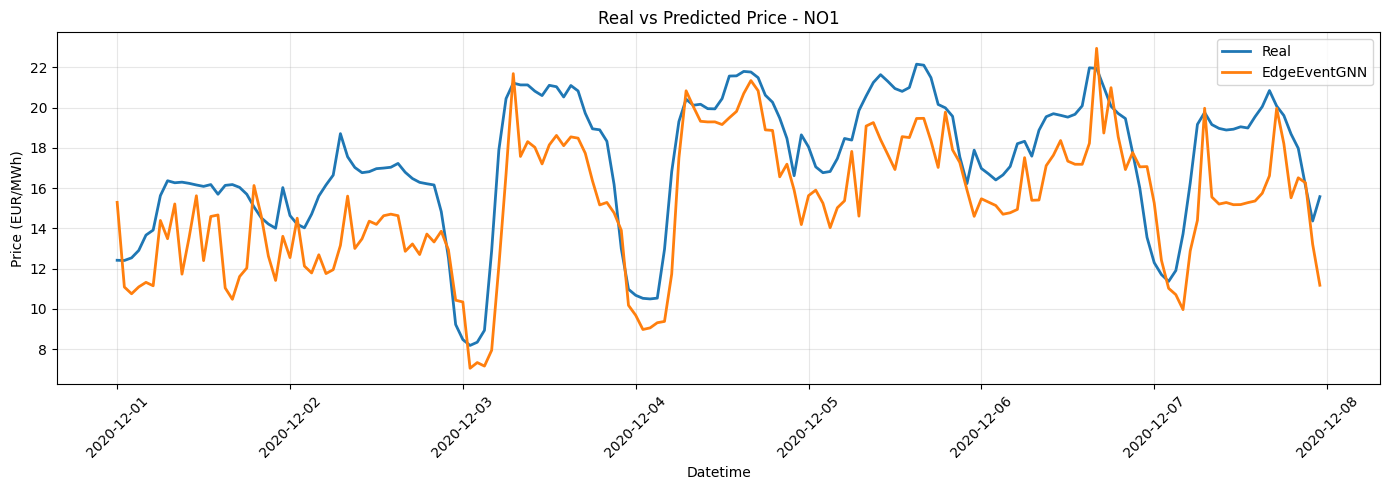

In [35]:
# ============================================================
# 26. PLOT EDGE EVENT GNN PREDICTIONS - SINGLE ZONE
# ============================================================

zone_to_plot = "NO1"

plot_df = (
    results_edge_event_gnn
    [results_edge_event_gnn["zone_code"] == zone_to_plot]
    .sort_values("datetime")
    .copy()
)

plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["datetime"],
    plot_df["y_true"],
    label="Real",
    linewidth=2
)

plt.plot(
    plot_df["datetime"],
    plot_df["y_pred"],
    label="EdgeEventGNN",
    linewidth=2
)

plt.title(f"Real vs Predicted Price - {zone_to_plot}")
plt.xlabel("Datetime")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

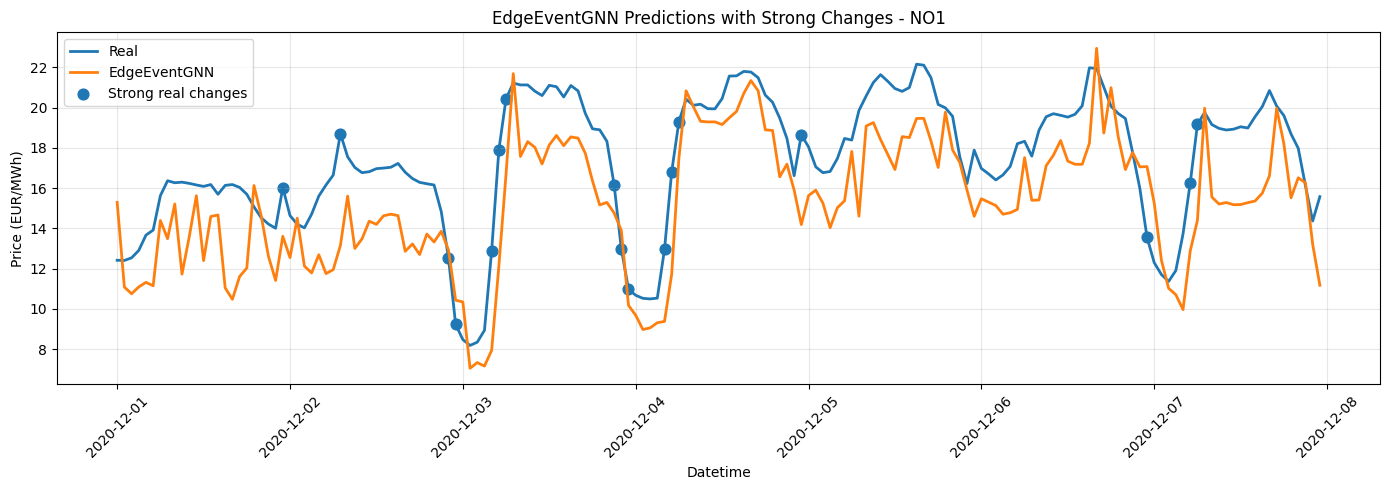

Strong change threshold: 2.0140004
Number of strong changes: 17


In [36]:
# ============================================================
# 27. PLOT EDGE EVENT GNN WITH STRONG CHANGES MARKED
# ============================================================

zone_to_plot = "NO1"

plot_df = (
    results_edge_event_gnn
    [results_edge_event_gnn["zone_code"] == zone_to_plot]
    .sort_values("datetime")
    .copy()
)

# Compute absolute real price changes for this zone
plot_df["true_delta"] = plot_df["y_true"].diff()
plot_df["abs_true_delta"] = plot_df["true_delta"].abs()

# Strong change threshold for this zone
zone_delta_p90 = plot_df["abs_true_delta"].quantile(0.90)

plot_df["strong_change"] = plot_df["abs_true_delta"] > zone_delta_p90

plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["datetime"],
    plot_df["y_true"],
    label="Real",
    linewidth=2
)

plt.plot(
    plot_df["datetime"],
    plot_df["y_pred"],
    label="EdgeEventGNN",
    linewidth=2
)

# Mark strong changes
strong_df = plot_df[plot_df["strong_change"]]

plt.scatter(
    strong_df["datetime"],
    strong_df["y_true"],
    label="Strong real changes",
    s=60,
    marker="o"
)

plt.title(f"EdgeEventGNN Predictions with Strong Changes - {zone_to_plot}")
plt.xlabel("Datetime")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Strong change threshold:", zone_delta_p90)
print("Number of strong changes:", plot_df["strong_change"].sum())

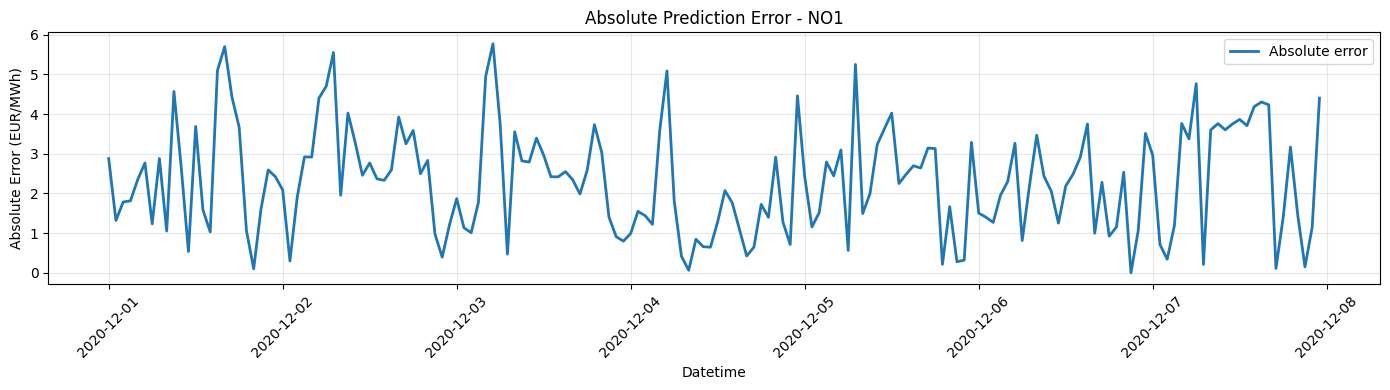

,datetime,zone_code,y_true,y_pred,abs_error
639,2020-12-03 05:00:00,NO1,17.900000,12.130614,5.769385
195,2020-12-01 16:00:00,NO1,16.180000,10.481389,5.698611
375,2020-12-02 07:00:00,NO1,18.709999,13.159581,5.550418
1239,2020-12-05 07:00:00,NO1,19.860001,14.611617,5.248384
183,2020-12-01 15:00:00,NO1,16.139999,11.045781,5.094218
927,2020-12-04 05:00:00,NO1,16.820000,11.735221,5.084779
627,2020-12-03 04:00:00,NO1,12.900000,7.949380,4.950620
1803,2020-12-07 06:00:00,NO1,19.170000,14.406652,4.763348
363,2020-12-02 06:00:00,NO1,16.650000,11.953550,4.696449
111,2020-12-01 09:00:00,NO1,16.299999,11.730779,4.569221


In [37]:
# ============================================================
# 28. PLOT ABSOLUTE ERROR - SINGLE ZONE
# ============================================================

zone_to_plot = "NO1"

plot_df = (
    results_edge_event_gnn
    [results_edge_event_gnn["zone_code"] == zone_to_plot]
    .sort_values("datetime")
    .copy()
)

plot_df["abs_error"] = (plot_df["y_true"] - plot_df["y_pred"]).abs()

plt.figure(figsize=(14, 4))

plt.plot(
    plot_df["datetime"],
    plot_df["abs_error"],
    label="Absolute error",
    linewidth=2
)

plt.title(f"Absolute Prediction Error - {zone_to_plot}")
plt.xlabel("Datetime")
plt.ylabel("Absolute Error (EUR/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(
    plot_df[["datetime", "zone_code", "y_true", "y_pred", "abs_error"]]
    .sort_values("abs_error", ascending=False)
    .head(10)
)

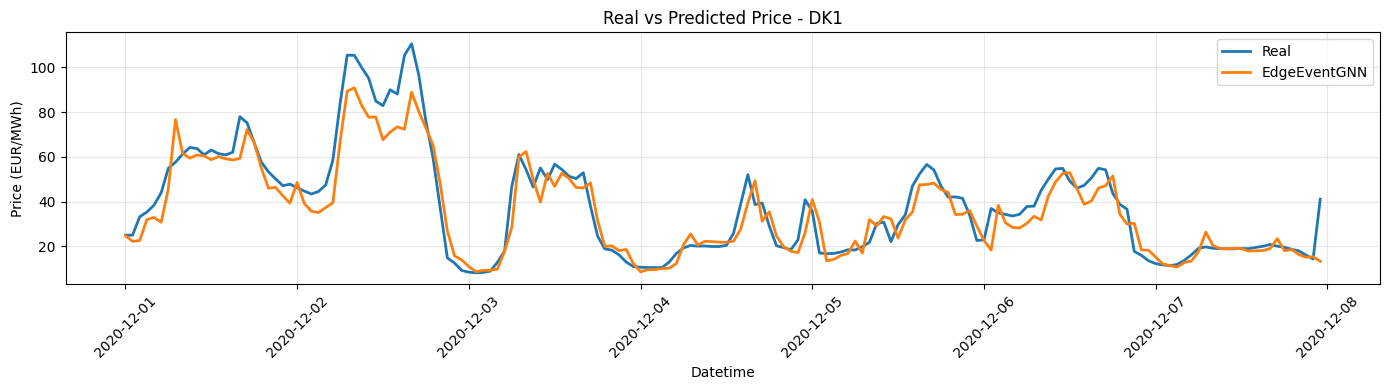

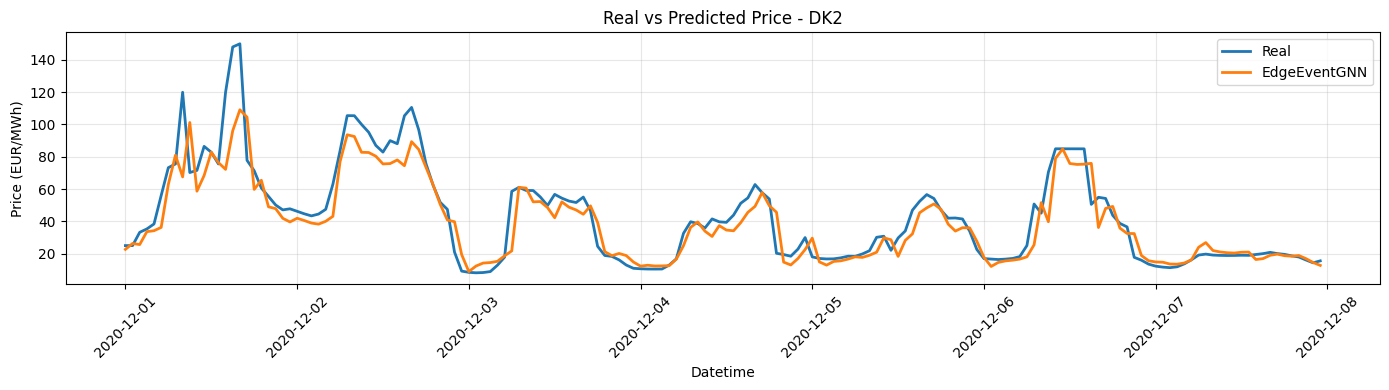

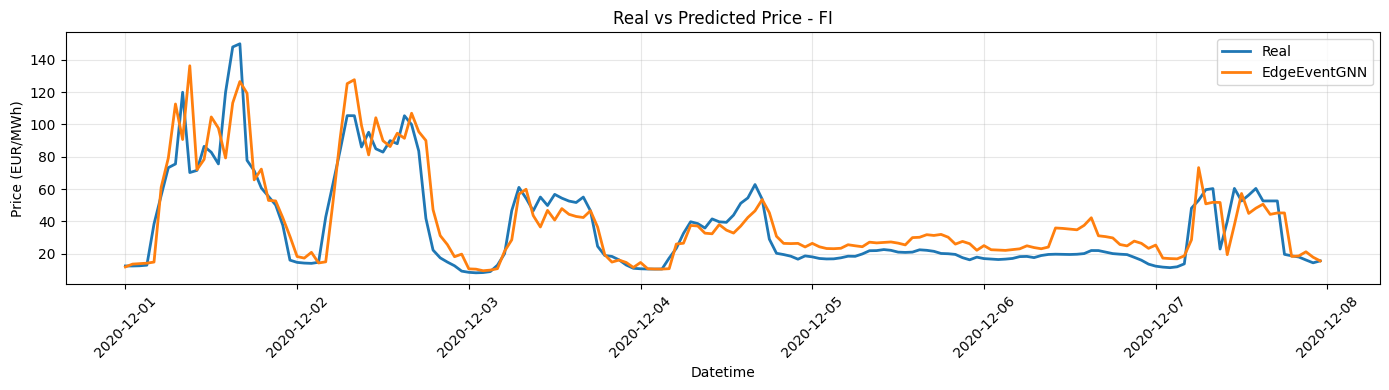

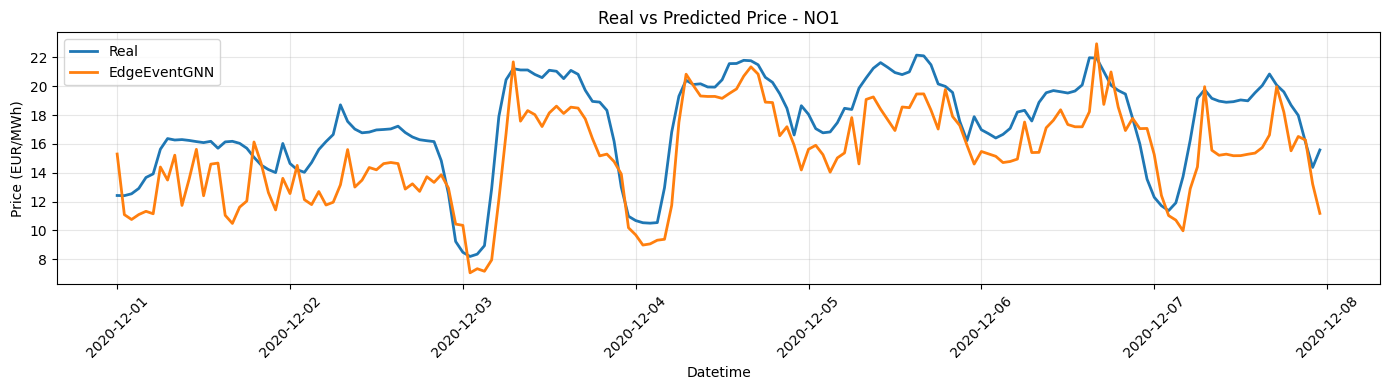

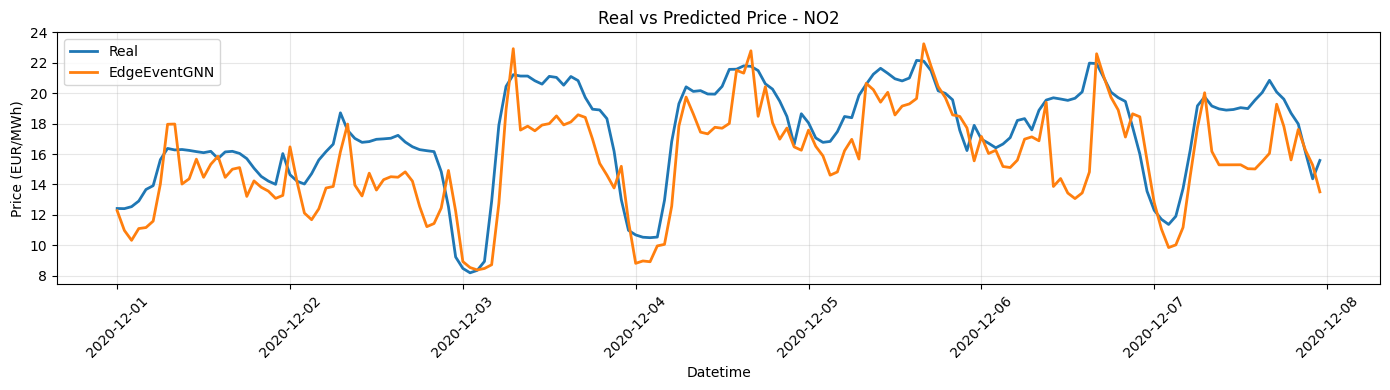

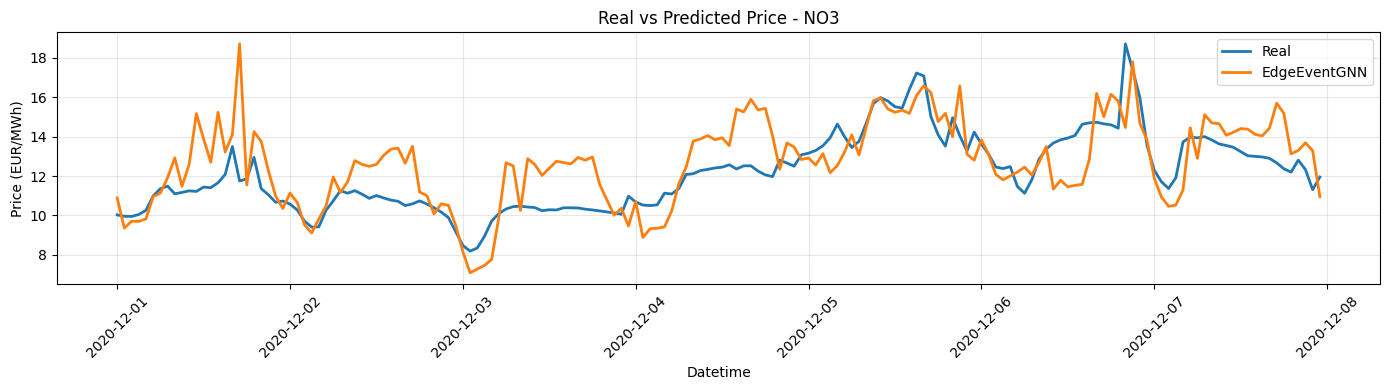

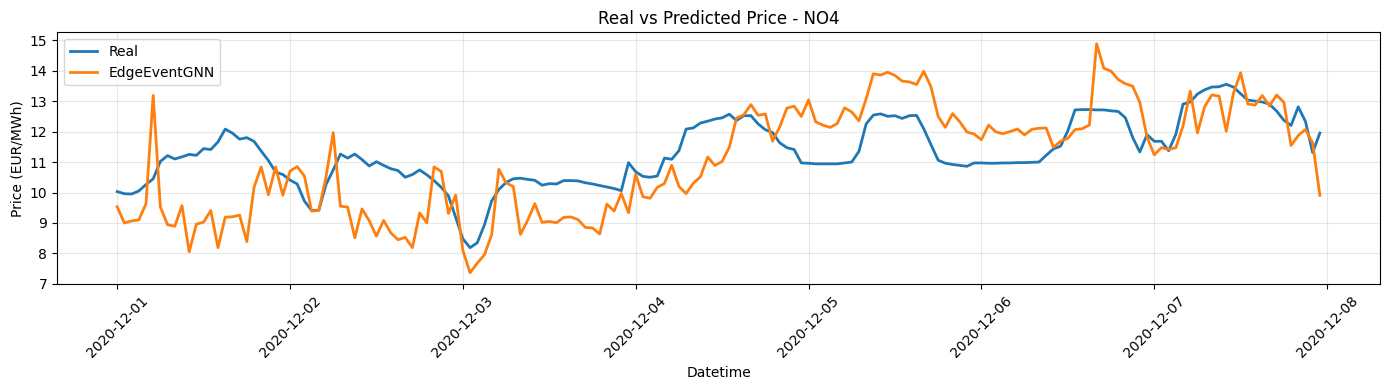

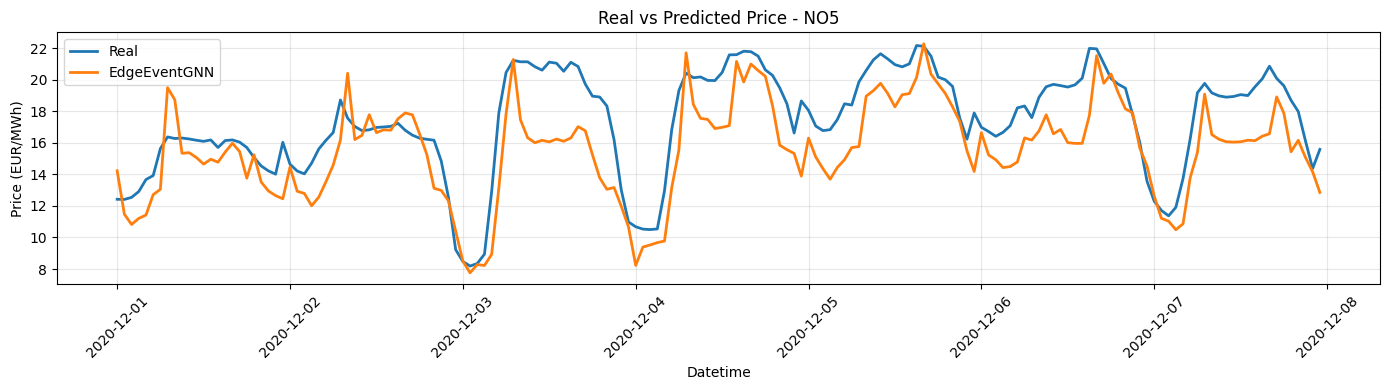

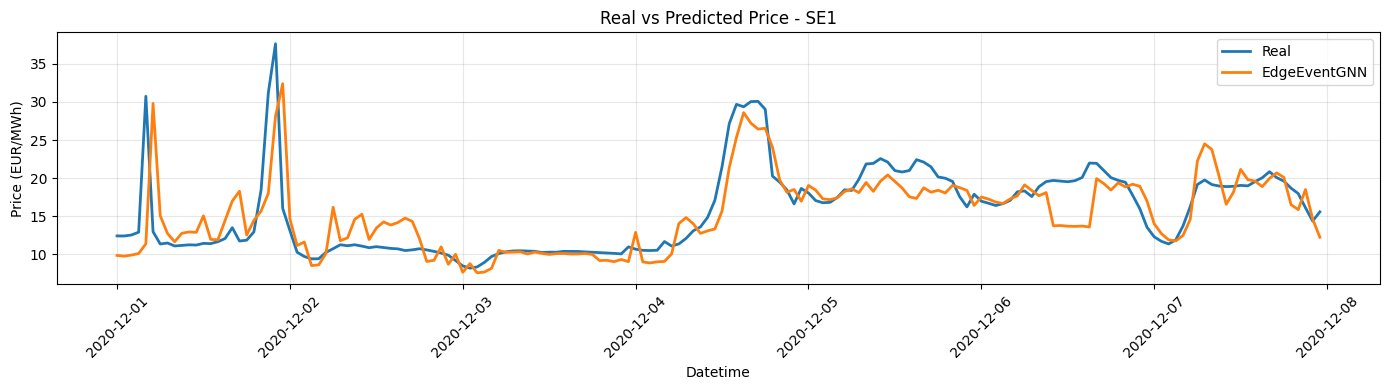

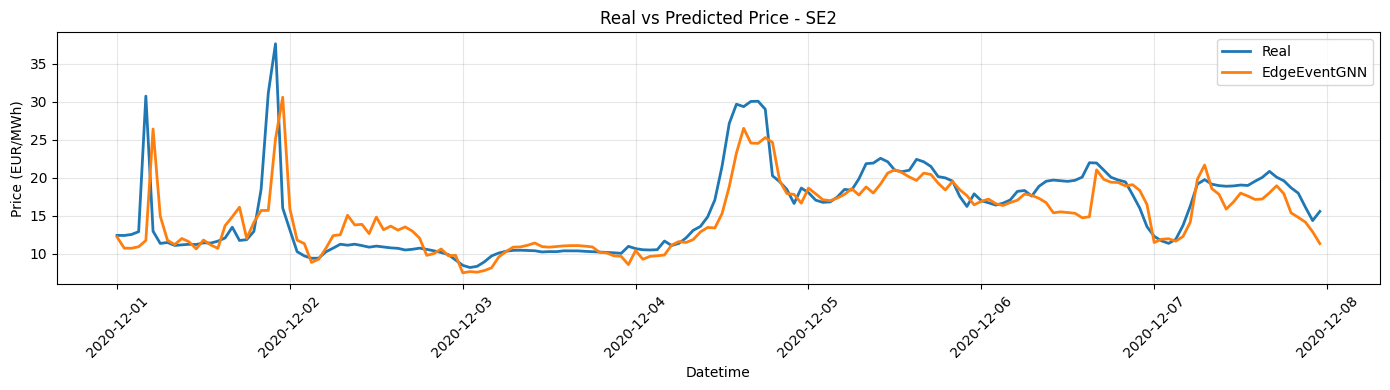

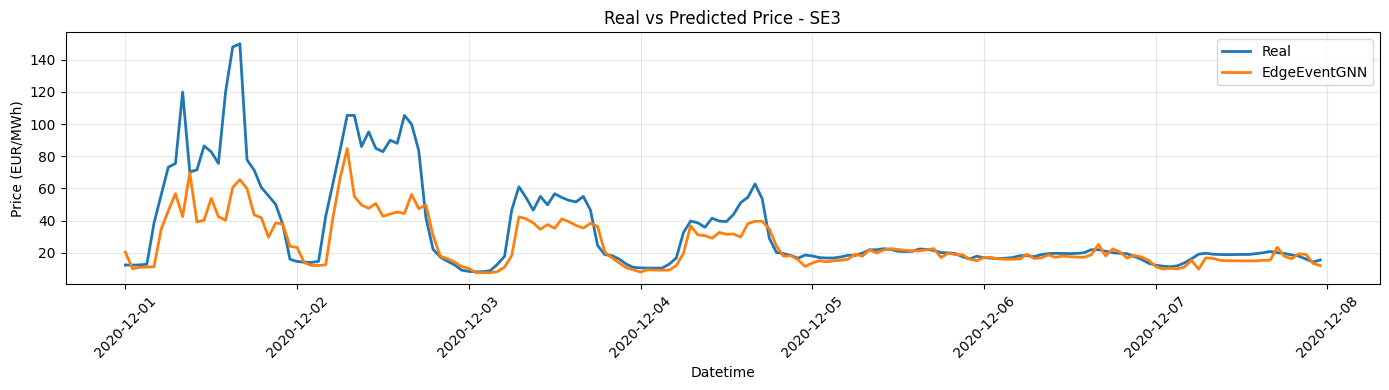

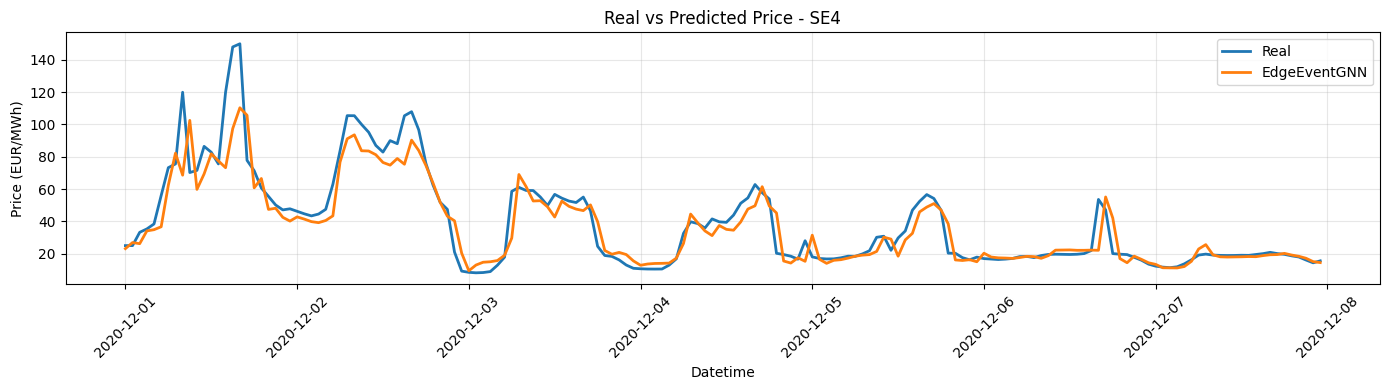

In [38]:
# ============================================================
# 29. PLOT EDGE EVENT GNN - ALL ZONES
# ============================================================

zones_to_plot = sorted(results_edge_event_gnn["zone_code"].unique())

for zone_to_plot in zones_to_plot:
    plot_df = (
        results_edge_event_gnn
        [results_edge_event_gnn["zone_code"] == zone_to_plot]
        .sort_values("datetime")
        .copy()
    )

    plt.figure(figsize=(14, 4))

    plt.plot(
        plot_df["datetime"],
        plot_df["y_true"],
        label="Real",
        linewidth=2
    )

    plt.plot(
        plot_df["datetime"],
        plot_df["y_pred"],
        label="EdgeEventGNN",
        linewidth=2
    )

    plt.title(f"Real vs Predicted Price - {zone_to_plot}")
    plt.xlabel("Datetime")
    plt.ylabel("Price (EUR/MWh)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()